<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# Instalar gdown (solo es necesario la primera vez)
!pip install gdown
# Descargar la carpeta con los datos
!gdown --folder --id 1GOJ63mZ6qZGdbb8v5v6bcy3fsbLs8yju
# Cargar el dataset en un DataFrame
import pandas as pd
df = pd.read_pickle('data/house_prices.pkl')

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Retrieving folder contents
Processing file 1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG data_description.txt
Processing file 1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF house_prices.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG
To: /content/data/data_description.txt
100% 13.4k/13.4k [00:00<00:00, 22.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF
To: /content/data/house_prices.pkl
100% 140k/140k [00:00<00:00, 58.7MB/s]
Download completed


#Ejercicio 1

In [61]:
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import pandas as pd
import numpy as np

def armar_resumen(df):
  """Construye la tabla de resumen de tipos y faltantes, manteniendo
  el % como numérico (para poder aplicarle color o graficarlo después)."""
  resumen = pd.DataFrame({
      'Tipo de Dato': df.dtypes.astype(str),
      'Datos Válidos (No Nulos)': df.notna().sum(),
      'Datos Faltantes (Nulos)': df.isna().sum(),
      '% de Faltantes': (df.isna().sum() / len(df) * 100).round(2),
  })
  return resumen.sort_values(by='Datos Faltantes (Nulos)', ascending=False)


def graficar_faltantes(resumen, umbral=0):
  """Barra horizontal con el % de faltantes por columna, para tener
  una lectura visual rápida antes de entrar al detalle de la tabla.
  umbral filtra columnas con menos de ese % (para no saturar el gráfico
  con columnas que tienen 0 o casi 0 faltantes)."""
  datos = resumen[resumen['% de Faltantes'] > umbral].sort_values('% de Faltantes')
  fig, ax = plt.subplots(figsize=(8, max(3, len(datos) * 0.3)))
  ax.barh(datos.index, datos['% de Faltantes'], color='#D85A30')
  ax.set_xlabel('% de Faltantes')
  ax.set_title('Variables con valores faltantes')
  for i, v in enumerate(datos['% de Faltantes']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
  plt.tight_layout()
  plt.show()


def explorar_categoricas(df, columnas=None, top_n=10):
  """Muestra value_counts de cada columna categórica, para detectar
  inconsistencias de nomenclatura (mayúsculas, espacios, typos) —
  consigna 1.2. Si no se pasan columnas, usa todas las object/category."""
  if columnas is None:
    columnas = df.select_dtypes(include=['object', 'category']).columns
  for col in columnas:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(top_n))
    print()

def graficar_antes_despues_categorias(antes_crudo, despues, orden_final,
                                        categoria_nueva='NONE',
                                        categorias_fusionadas=('NA', 'NAN')):
  """Grafica en dos paneles lado a lado la distribución de una variable
  categórica: a la izquierda, las categorías originales (incluyendo el
  faltante real, mostrado como 'NAN', y la categoría de texto 'NA' por
  separado); a la derecha, la distribución final ya unificada. Resalta
  en color distinto las categorías afectadas por la transformación."""

  normalizado = antes_crudo.astype('string').str.strip().str.upper()
  normalizado = normalizado.fillna('NAN')
  conteo_antes = normalizado.value_counts().sort_values(ascending=False)

  conteo_despues = despues.value_counts().reindex(orden_final, fill_value=0)

  color_normal, color_afectado = '#5F5E5A', '#D85A30'
  colores_antes = [color_afectado if c in categorias_fusionadas else color_normal for c in conteo_antes.index]
  colores_despues = [color_afectado if c == categoria_nueva else color_normal for c in conteo_despues.index]

  fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

  axes[0].barh(conteo_antes.index.astype(str), conteo_antes.values, color=colores_antes)
  axes[0].invert_yaxis()
  axes[0].set_title('Antes: categorías originales')
  axes[0].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_antes.values):
    axes[0].text(v + max(conteo_antes.values) * 0.01, i, str(v), va='center', fontsize=9)

  axes[1].barh(conteo_despues.index.astype(str), conteo_despues.values, color=colores_despues)
  axes[1].invert_yaxis()
  axes[1].set_title('Después: categorías unificadas')
  axes[1].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_despues.values):
    axes[1].text(v + max(conteo_despues.values) * 0.01, i, str(v), va='center', fontsize=9)

  plt.tight_layout()
  plt.show()

In [67]:
#Chequeamos que son int64 y float64 respectivamente
assert df['SalePrice'].dtype == 'int64'
assert df['LotFrontage'].dtype == 'float64'

resumen = armar_resumen(df)

display(resumen)
graficar_faltantes(resumen, umbral=0)
df.head()


AssertionError: 

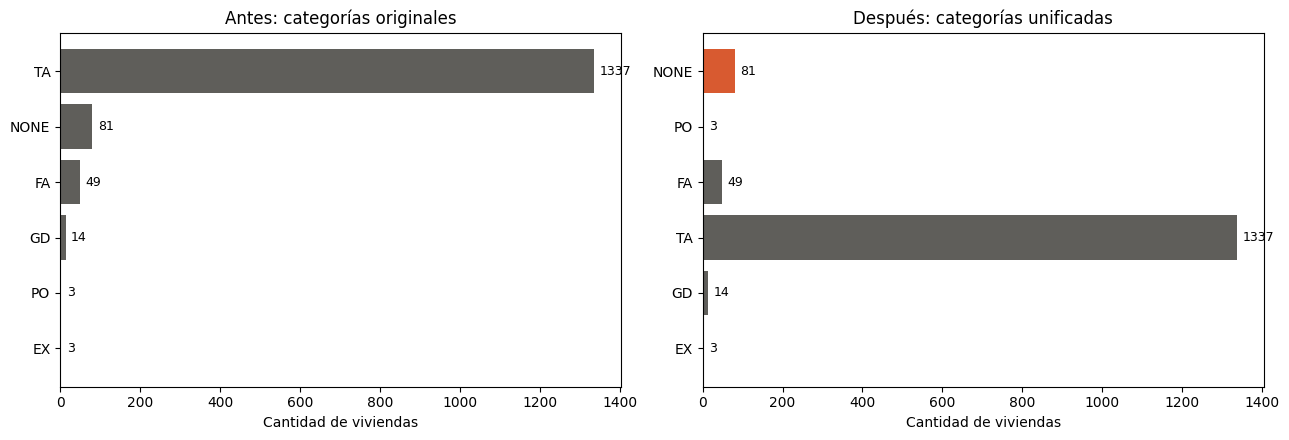

In [66]:
df_antes = df['GarageQual'].copy()
df['GarageQual'].value_counts(dropna=False)
#Se puede observar que hay una falsa categoría: NaN y NA porbablemente hagan referencia a la clase "Na": que no tiene garage.
#Estrategia adoptadas: pasamos todo a mayúsculas, y fusionamos estas dos categorías.
df['GarageQual'] = df['GarageQual'].str.strip().str.upper() # strip() elimina espacios en blanco al principio y al final de cada texto.
#Vamos a determinar si los NaN son faltantes o si hacen referencia a la categoría "Na"
df.loc[df['GarageQual'].isna(), 'GarageArea'].value_counts() #Podemos ver que todos los NaN de GarageQual eran en realidad "Na" (o indica que no hay garage)

sin_garage = df['GarageArea'] == 0
df.loc[sin_garage, 'GarageQual'] = 'NONE'
df['GarageQual'] = df['GarageQual'].replace({'NA': 'NONE'})

orden_calidad_Grid = CategoricalDtype(categories = ['NONE', 'PO', 'FA', 'TA', 'GD', 'EX'], ordered = True)
df['GarageQual'] = df['GarageQual'].astype(orden_calidad_Grid)
assert df['GarageQual'].isna().sum() == 0, "Quedaron valores sin mapear al hacer el cast"

graficar_antes_despues_categorias(antes_crudo=df_antes, despues=df['GarageQual'], orden_final=['NONE', 'PO', 'FA', 'TA', 'GD', 'EX'])

Resumen de variables

Las variables corresponden al dataset de Ames Housing (comúnmente usado en la competencia *House Prices* de Kaggle):

* **SalePrice:** Precio de venta de la propiedad en dólares (variable objetivo / target).
* **MSZoning:** Clasificación general de zonificación del terreno (ej. residencial de baja densidad 'RL', residencial de media densidad 'RM', comercial 'C', etc.).
* **Neighborhood:** Ubicación física o barrio dentro de los límites de la ciudad de Ames (ej. `NAmes`, `CollgCr`, `OldTown`).
* **LotFrontage:** Longitud lineal en pies (ft) de la calle conectada con la propiedad (frente del lote).
* **LotArea:** Tamaño total del lote o terreno en pies cuadrados ($ft^2$).
* **OverallCond:** Calificación general del estado/condición de la vivienda en una escala del 1 (muy pobre) al 10 (muy excelente).
* **YearBuilt:** Año original de construcción de la propiedad.
* **FullBath:** Cantidad de baños completos ubicados por encima del nivel del suelo (*above ground*).
* **BedroomAbvGr:** Cantidad de dormitorios ubicados por encima del nivel del suelo (excluye dormitorios en el sótano/basement).
* **GarageQual:** Calidad del garaje (ej. `Ex` Excelente, `Gd` Bueno, `TA` Típico/Promedio, `Fa` Regular, `Po` Pobre, `NA` Sin garaje).
* **GarageArea:** Tamaño total del garaje en pies cuadrados ($ft^2$).
* **PoolArea:** Superficie de la piscina en pies cuadrados ($ft^2$).
* **PoolQC:** Calidad de la piscina (ej. `Ex`, `Gd`, `TA`, `Fa`, `NA` si no tiene piscina).
* **Fence:** Calidad y privacidad de la cerca o cercado (ej. `GdPrv` Buena privacidad, `MnPrv` Mínima privacidad, `GdWo` Buena madera, `MnWw` Mínima madera/alambre, `NA` Sin cerca).


In [55]:
print(df['SalePrice'].dtype)
print(df['LotFrontage'].dtype)

object
object
